In [2]:
# Importa o Keras, que será utilizado para carregar as imagens
import keras

# Define o caminho da pasta de treinamento
diretorio_treino = r"C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\dogs_vs_cats\train"

# Define o caminho da pasta de validação
diretorio_validacao = r"C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\dogs_vs_cats\val"

# Define o tamanho das imagens que serão utilizadas pela CNN
tamanho_imagem = (256, 256)

# Define quantas imagens serão processadas por lote
tamanho_lote = 32

In [3]:
# Carrega as imagens da pasta de treinamento
dataset_treino = keras.utils.image_dataset_from_directory(
    # Indica onde estão as pastas cat e dog
    diretorio_treino,

    # Define o tamanho do lote de imagens processadas por vez
    batch_size=tamanho_lote,

    # Redimensiona todas as imagens para 256x256 pixels
    image_size=tamanho_imagem,

    # Define uma semente para manter a ordem dos dados reproduzível
    seed=123
)

# Mostra os nomes das classes encontrados nas pastas
print("Classes:", dataset_treino.class_names)

Found 11521 files belonging to 2 classes.
Classes: ['cat', 'dog']


In [4]:
# Carrega as imagens da pasta de validação
dataset_validacao = keras.utils.image_dataset_from_directory(
    # Indica onde estão as pastas cat e dog
    diretorio_validacao,

    # Define o tamanho do lote de imagens processadas por vez
    batch_size=tamanho_lote,

    # Redimensiona todas as imagens para 256x256 pixels
    image_size=tamanho_imagem,

    # Usa a mesma semente do dataset de treinamento
    seed=123
)

# Mostra os nomes das classes encontrados na validação
print("Classes:", dataset_validacao.class_names)

Found 2882 files belonging to 2 classes.
Classes: ['cat', 'dog']


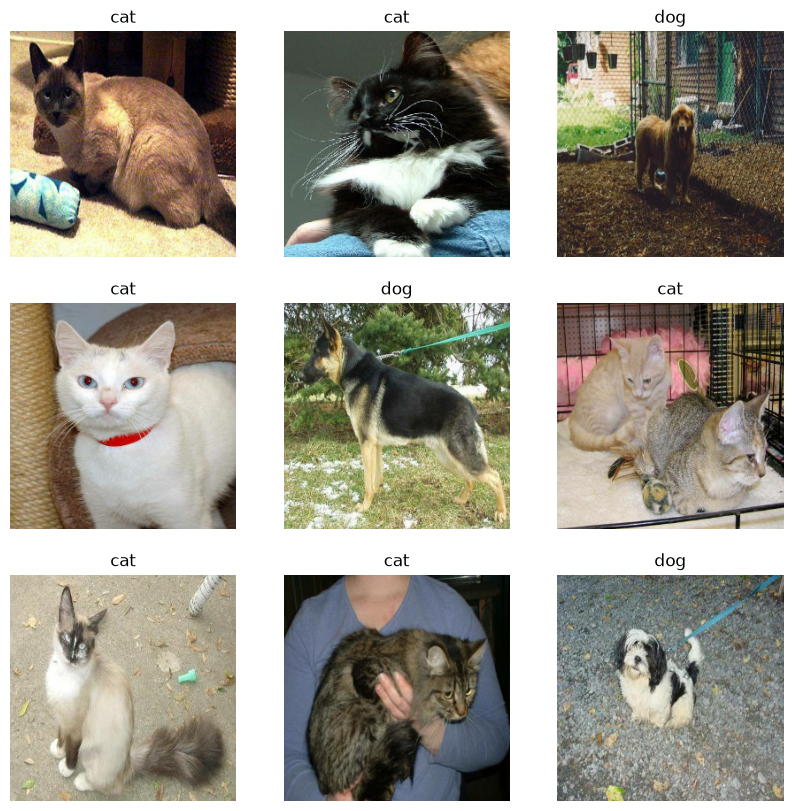

In [6]:
# Importa o Matplotlib para visualizar as imagens
import matplotlib.pyplot as plt

# Pega um lote de imagens e seus respectivos rótulos do dataset de treinamento
imagens, rotulos = next(iter(dataset_treino))

# Cria uma figura com 9 espaços para mostrar as imagens
plt.figure(figsize=(10, 10))

# Percorre as 9 primeiras imagens do lote
for i in range(9):
    # Cria um espaço individual para a imagem
    ax = plt.subplot(3, 3, i + 1)

    # Mostra a imagem
    plt.imshow(imagens[i].numpy().astype("uint8"))

    # Mostra o nome da classe correspondente ao rótulo
    plt.title(dataset_treino.class_names[rotulos[i]])

    # Remove os eixos para deixar a visualização mais limpa
    plt.axis("off")

# Exibe todas as imagens
plt.show()

In [7]:
# Organiza o dataset de treinamento para melhorar o desempenho durante o treinamento
dataset_treino = dataset_treino.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

# Organiza o dataset de validação para melhorar o desempenho durante a validação
dataset_validacao = dataset_validacao.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [8]:
# Importa as camadas e o modelo sequencial do Keras
from tensorflow.keras import layers, models

# Cria a arquitetura da rede neural convolucional
modelo = models.Sequential([

    # Define o formato das imagens de entrada: 256x256 pixels e 3 canais de cor
    layers.Input(shape=(256, 256, 3)),

    # Inverte horizontalmente algumas imagens para aumentar a variedade dos dados
    layers.RandomFlip("horizontal"),

    # Aplica pequenas rotações aleatórias nas imagens
    layers.RandomRotation(0.15),

    # Aplica pequenos zooms aleatórios nas imagens
    layers.RandomZoom(0.1),

    # Converte os pixels de 0-255 para valores entre 0 e 1
    layers.Rescaling(1./255),

    # Primeira camada convolucional para identificar características básicas das imagens
    layers.Conv2D(32, (3, 3), activation='relu'),

    # Reduz o tamanho espacial das características encontradas
    layers.MaxPooling2D(2, 2),

    # Segunda camada convolucional para identificar características mais complexas
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Reduz novamente o tamanho das características
    layers.MaxPooling2D(2, 2),

    # Transforma os mapas de características em um vetor
    layers.Flatten(),

    # Camada totalmente conectada para aprender combinações das características
    layers.Dense(128, activation='relu'),

    # Desativa aleatoriamente parte dos neurônios para reduzir overfitting
    layers.Dropout(0.2),

    # Um único neurônio para classificação binária: cat ou dog
    layers.Dense(1, activation='sigmoid')
])

# Exibe um resumo da arquitetura e da quantidade de parâmetros
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,509,697 (120.20 MB)

 Trainable params: 31,509,697 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Configura o modelo para o processo de treinamento
modelo.compile(

    # Utiliza o otimizador Adam para atualizar os pesos da rede
    optimizer='adam',

    # Utiliza binary_crossentropy porque temos apenas duas classes
    loss='binary_crossentropy',

    # Acompanha a acurácia durante o treinamento e a validação
    metrics=['accuracy']
)

In [10]:
# Importa o callback EarlyStopping, utilizado para interromper o treinamento
# quando a validação deixa de melhorar
from tensorflow.keras.callbacks import EarlyStopping

# Cria a configuração de parada antecipada
parada_antecipada = EarlyStopping(

    # Monitora a perda calculada no conjunto de validação
    monitor='val_loss',

    # Aguarda até 5 épocas sem melhoria antes de interromper
    patience=5,

    # Recupera os pesos do modelo que apresentou a melhor val_loss
    restore_best_weights=True,

    # Mostra uma mensagem no notebook quando o treinamento for interrompido
    verbose=1
)

In [11]:
# Inicia o treinamento do modelo
historico_tratado = modelo.fit(

    # Utiliza o conjunto de imagens de treinamento
    dataset_treino,

    # Define o número máximo de épocas
    epochs=10,

    # Utiliza o conjunto de validação para acompanhar o desempenho
    validation_data=dataset_validacao,

    # Utiliza o EarlyStopping para interromper o treinamento
    # caso a validação deixe de melhorar
    callbacks=[parada_antecipada]
)

Epoch 1/10


c:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


361/361 ━━━━━━━━━━━━━━━━━━━━ 575s 1s/step - accuracy: 0.5747 - loss: 0.7739 - val_accuracy: 0.6509 - val_loss: 0.6611
Epoch 2/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.6344 - loss: 0.6347 - val_accuracy: 0.6881 - val_loss: 0.5774
Epoch 3/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 528s 1s/step - accuracy: 0.6756 - loss: 0.6018 - val_accuracy: 0.7065 - val_loss: 0.5494
Epoch 4/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.6867 - loss: 0.5866 - val_accuracy: 0.7457 - val_loss: 0.5177
Epoch 5/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - accuracy: 0.7082 - loss: 0.5673 - val_accuracy: 0.7366 - val_loss: 0.5216
Epoch 6/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.7144 - loss: 0.5543 - val_accuracy: 0.7283 - val_loss: 0.5235
Epoch 7/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.7260 - loss: 0.5387 - val_accuracy: 0.7693 - val_loss: 0.4828
Epoch 8/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.7339 - loss: 0.5302 - val_accuracy: 0.756

In [12]:
# Importa o NumPy para trabalhar com os arrays de previsões
import numpy as np

# Cria listas para armazenar os rótulos verdadeiros e as previsões do modelo
rotulos_verdadeiros = []
previsoes = []

# Percorre todas as imagens e rótulos do conjunto de validação
for imagens, rotulos in dataset_validacao:

    # Faz as previsões para o lote atual de imagens
    resultado = modelo.predict(imagens, verbose=0)

    # Armazena os rótulos verdadeiros das imagens
    rotulos_verdadeiros.extend(rotulos.numpy())

    # Armazena as probabilidades previstas pelo modelo
    previsoes.extend(resultado.flatten())

# Converte as listas para arrays NumPy
rotulos_verdadeiros = np.array(rotulos_verdadeiros)
previsoes = np.array(previsoes)

# Converte as probabilidades em classes:
# valores menores que 0.5 → gato (0)
# valores maiores ou iguais a 0.5 → cachorro (1)
previsoes_classes = (previsoes >= 0.5).astype(int)

# Mostra algumas informações para conferirmos o resultado
print("Quantidade de imagens avaliadas:", len(rotulos_verdadeiros))
print("Primeiras probabilidades:", previsoes[:10])
print("Primeiras classes previstas:", previsoes_classes[:10])
print("Primeiros rótulos verdadeiros:", rotulos_verdadeiros[:10])

Quantidade de imagens avaliadas: 2882
Primeiras probabilidades: [0.27602237 0.2844089  0.925611   0.3035507  0.44332334 0.2135506
 0.89754444 0.961041   0.4865253  0.93893844]
Primeiras classes previstas: [0 0 1 0 0 0 1 1 0 1]
Primeiros rótulos verdadeiros: [0 0 1 0 1 1 1 1 1 1]


In [14]:
# Importa a função responsável por calcular a matriz de confusão
from sklearn.metrics import confusion_matrix

# Calcula a matriz comparando os rótulos verdadeiros
# com as classes previstas pela CNN
matriz = confusion_matrix(
    rotulos_verdadeiros,
    previsoes_classes
)

# Exibe a matriz no terminal
print(matriz)

[[1146  295]
 [ 378 1063]]


In [18]:
# Importa o Matplotlib para criar o mapa de calor
import matplotlib.pyplot as plt

# Importa o NumPy para trabalhar com a matriz de confusão
import numpy as np

# Importa o Seaborn para facilitar a criação do mapa de calor
import seaborn as sns

# Importa o ImageIO para juntar as imagens e criar o GIF
import imageio.v2 as imageio

# Importa o Path para trabalhar com os caminhos das pastas e arquivos
from pathlib import Path

In [19]:
# Define o caminho da pasta onde vamos salvar o GIF
pasta_resultados = Path(
    r"C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao"
)

# Cria a pasta caso ela ainda não exista
pasta_resultados.mkdir(parents=True, exist_ok=True)

# Mostra o caminho para confirmar onde o arquivo será salvo
print("Pasta de resultados:", pasta_resultados)

Pasta de resultados: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao


In [20]:
# Cria a matriz de confusão com os valores obtidos na validação
matriz = np.array([
    [1146, 295],
    [378, 1063]
])

# Mostra a matriz no notebook para conferência
print(matriz)

[[1146  295]
 [ 378 1063]]


In [21]:
# Cria uma figura para o primeiro quadro da animação
fig, ax = plt.subplots(figsize=(8, 6))

# Cria uma matriz vazia com o mesmo tamanho da matriz de confusão
matriz_vazia = np.zeros_like(matriz)

# Cria o mapa de calor usando a matriz vazia
sns.heatmap(
    matriz_vazia,
    annot=False,
    cmap="Blues",
    cbar=True,
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"],
    ax=ax
)

# Define o título do mapa de calor
ax.set_title("Matriz de Confusão — CNN Cães vs Gatos")

# Define o nome do eixo horizontal
ax.set_xlabel("Classe prevista")

# Define o nome do eixo vertical
ax.set_ylabel("Classe real")

# Ajusta o espaçamento da figura
plt.tight_layout()

# Define o caminho onde o primeiro quadro será salvo
caminho_quadro = pasta_resultados / "quadro_01.png"

# Salva o primeiro quadro como imagem PNG
plt.savefig(caminho_quadro, dpi=150)

# Fecha a figura para liberar memória
plt.close()

# Confirma onde o quadro foi salvo
print("Quadro salvo em:", caminho_quadro)

Quadro salvo em: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\quadro_01.png


In [22]:
# Cria uma nova figura para o segundo quadro da animação
fig, ax = plt.subplots(figsize=(8, 6))

# Cria uma cópia da matriz para preencher somente a primeira posição
matriz_quadro = np.zeros_like(matriz)

# Adiciona o primeiro resultado da matriz:
# 1146 gatos foram classificados corretamente como gatos
matriz_quadro[0, 0] = matriz[0, 0]

# Cria o mapa de calor com o primeiro valor preenchido
sns.heatmap(
    matriz_quadro,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"],
    ax=ax
)

# Define o título do mapa de calor
ax.set_title("Matriz de Confusão — CNN Cães vs Gatos")

# Define o nome do eixo horizontal
ax.set_xlabel("Classe prevista")

# Define o nome do eixo vertical
ax.set_ylabel("Classe real")

# Ajusta o espaçamento da figura
plt.tight_layout()

# Define o caminho para salvar o segundo quadro
caminho_quadro = pasta_resultados / "quadro_02.png"

# Salva o quadro como uma imagem PNG
plt.savefig(caminho_quadro, dpi=150)

# Fecha a figura para liberar memória
plt.close()

# Confirma onde o quadro foi salvo
print("Quadro salvo em:", caminho_quadro)

Quadro salvo em: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\quadro_02.png


In [23]:
# Cria uma nova figura para o terceiro quadro da animação
fig, ax = plt.subplots(figsize=(8, 6))

# Cria uma cópia da matriz para controlar quais valores já aparecem
matriz_quadro = np.zeros_like(matriz)

# Adiciona o primeiro resultado:
# 1146 gatos foram classificados corretamente como gatos
matriz_quadro[0, 0] = matriz[0, 0]

# Adiciona o segundo resultado:
# 295 gatos foram classificados incorretamente como cachorros
matriz_quadro[0, 1] = matriz[0, 1]

# Cria o mapa de calor com os dois primeiros resultados
sns.heatmap(
    matriz_quadro,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"],
    ax=ax
)

# Define o título do mapa de calor
ax.set_title("Matriz de Confusão — CNN Cães vs Gatos")

# Define o nome do eixo horizontal
ax.set_xlabel("Classe prevista")

# Define o nome do eixo vertical
ax.set_ylabel("Classe real")

# Ajusta o espaçamento da figura
plt.tight_layout()

# Define o caminho para salvar o terceiro quadro
caminho_quadro = pasta_resultados / "quadro_03.png"

# Salva o quadro como uma imagem PNG
plt.savefig(caminho_quadro, dpi=150)

# Fecha a figura para liberar memória
plt.close()

# Confirma onde o quadro foi salvo
print("Quadro salvo em:", caminho_quadro)

Quadro salvo em: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\quadro_03.png


In [24]:
# Cria uma nova figura para o quarto quadro da animação
fig, ax = plt.subplots(figsize=(8, 6))

# Cria uma cópia da matriz para controlar os valores já exibidos
matriz_quadro = np.zeros_like(matriz)

# Adiciona o primeiro resultado:
# 1146 gatos foram classificados corretamente como gatos
matriz_quadro[0, 0] = matriz[0, 0]

# Adiciona o segundo resultado:
# 295 gatos foram classificados incorretamente como cachorros
matriz_quadro[0, 1] = matriz[0, 1]

# Adiciona o terceiro resultado:
# 378 cachorros foram classificados incorretamente como gatos
matriz_quadro[1, 0] = matriz[1, 0]

# Cria o mapa de calor com os três resultados preenchidos
sns.heatmap(
    matriz_quadro,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"],
    ax=ax
)

# Define o título do mapa de calor
ax.set_title("Matriz de Confusão — CNN Cães vs Gatos")

# Define o nome do eixo horizontal
ax.set_xlabel("Classe prevista")

# Define o nome do eixo vertical
ax.set_ylabel("Classe real")

# Ajusta o espaçamento da figura
plt.tight_layout()

# Define o caminho para salvar o quarto quadro
caminho_quadro = pasta_resultados / "quadro_04.png"

# Salva o quadro como uma imagem PNG
plt.savefig(caminho_quadro, dpi=150)

# Fecha a figura para liberar memória
plt.close()

# Confirma onde o quadro foi salvo
print("Quadro salvo em:", caminho_quadro)

Quadro salvo em: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\quadro_04.png


In [25]:
# Cria uma nova figura para o último quadro da animação
fig, ax = plt.subplots(figsize=(8, 6))

# Cria uma cópia da matriz original para mostrar todos os resultados
matriz_quadro = matriz.copy()

# Cria o mapa de calor com a matriz completa
sns.heatmap(
    matriz_quadro,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"],
    ax=ax
)

# Define o título do mapa de calor
ax.set_title("Matriz de Confusão — CNN Cães vs Gatos")

# Define o nome do eixo horizontal
ax.set_xlabel("Classe prevista")

# Define o nome do eixo vertical
ax.set_ylabel("Classe real")

# Ajusta o espaçamento da figura
plt.tight_layout()

# Define o caminho para salvar o último quadro
caminho_quadro = pasta_resultados / "quadro_05.png"

# Salva o quadro completo como PNG
plt.savefig(caminho_quadro, dpi=150)

# Fecha a figura para liberar memória
plt.close()

# Confirma onde o quadro foi salvo
print("Quadro completo salvo em:", caminho_quadro)

Quadro completo salvo em: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\quadro_05.png


In [30]:
# Cria uma lista para armazenar todos os quadros da animação
quadros = []

# Percorre os cinco quadros na ordem da animação
for numero in range(1, 6):

    # Monta o caminho do arquivo PNG correspondente ao quadro
    caminho_quadro = pasta_resultados / f"quadro_{numero:02d}.png"

    # Lê o arquivo PNG e adiciona a imagem à lista
    quadros.append(imageio.imread(caminho_quadro))

# Define o caminho onde o GIF será salvo
caminho_gif = pasta_resultados / "matriz_confusao_cnn.gif"

# Cria o GIF deixando cada quadro visível por 25 segundos
imageio.mimsave(
    caminho_gif,
    quadros,
    duration=25.0,
    loop=0
)

# Confirma que o GIF foi criado
print("GIF criado com 25 segundos por quadro!")
print("Duração de cada ciclo: 125 segundos")
print("Arquivo:", caminho_gif)

GIF criado com 25 segundos por quadro!
Duração de cada ciclo: 125 segundos
Arquivo: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\matriz_confusao_cnn.gif


In [31]:
# Importa o NumPy para realizar a mistura entre duas imagens
import numpy as np

# Importa o ImageIO para ler e salvar as imagens
import imageio.v2 as imageio

# Lista que armazenará todos os quadros, incluindo as transições
quadros_animacao = []

# Quantidade de quadros intermediários entre duas imagens
quantidade_transicao = 20

# Percorre os cinco quadros originais
for numero in range(1, 6):

    # Monta o caminho do quadro atual
    caminho_atual = pasta_resultados / f"quadro_{numero:02d}.png"

    # Lê o quadro atual
    imagem_atual = imageio.imread(caminho_atual)

    # Adiciona o quadro atual à animação
    quadros_animacao.append(imagem_atual)

    # Verifica se existe um próximo quadro
    if numero < 5:

        # Monta o caminho do próximo quadro
        caminho_proximo = pasta_resultados / f"quadro_{numero + 1:02d}.png"

        # Lê o próximo quadro
        imagem_proxima = imageio.imread(caminho_proximo)

        # Cria os quadros intermediários da transição
        for etapa in range(1, quantidade_transicao + 1):

            # Calcula o nível de mistura entre as duas imagens
            alpha = etapa / (quantidade_transicao + 1)

            # Mistura gradualmente a imagem atual com a próxima
            imagem_transicao = (
                imagem_atual * (1 - alpha)
                + imagem_proxima * alpha
            ).astype(np.uint8)

            # Adiciona a imagem intermediária à animação
            quadros_animacao.append(imagem_transicao)

# Mostra quantos quadros foram criados
print("Quantidade total de quadros:", len(quadros_animacao))

Quantidade total de quadros: 85


In [32]:
# Define o caminho onde o GIF final será salvo
caminho_gif = pasta_resultados / "matriz_confusao_cnn_suave.gif"

# Cria uma lista para armazenar o tempo de exibição de cada quadro
duracoes = []

# Percorre os 85 quadros da animação
for indice in range(len(quadros_animacao)):

    # Os quadros principais são os quadros 1, 22, 43, 64 e 85
    # Eles permanecem mais tempo na tela para facilitar a leitura
    if indice in [0, 21, 42, 63, 84]:

        # Mantém o quadro principal por 5 segundos
        duracoes.append(5.0)

    else:

        # Mantém cada quadro intermediário por 0.1 segundo
        duracoes.append(0.1)

# Cria o GIF utilizando todos os quadros e suas respectivas durações
imageio.mimsave(
    caminho_gif,
    quadros_animacao,
    duration=duracoes,
    loop=0
)

# Confirma que o GIF foi criado
print("GIF com transição suave criado!")
print("Arquivo:", caminho_gif)
print("Quantidade de quadros:", len(quadros_animacao))

GIF com transição suave criado!
Arquivo: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\matriz_confusao_cnn_suave.gif
Quantidade de quadros: 85


In [33]:
# Importa a função que calcula as principais métricas de classificação
from sklearn.metrics import classification_report

# Calcula o relatório usando os rótulos verdadeiros e as classes previstas
relatorio = classification_report(
    rotulos_verdadeiros,
    previsoes_classes,
    target_names=["Cat", "Dog"]
)

# Exibe o relatório no notebook
print(relatorio)

              precision    recall  f1-score   support

         Cat       0.75      0.80      0.77      1441
         Dog       0.78      0.74      0.76      1441

    accuracy                           0.77      2882
   macro avg       0.77      0.77      0.77      2882
weighted avg       0.77      0.77      0.77      2882



In [34]:
# Cria um dicionário com as métricas obtidas no Classification Report
metricas = {
    "Cat": {
        "Precision": 0.75,
        "Recall": 0.80,
        "F1-score": 0.77
    },
    "Dog": {
        "Precision": 0.78,
        "Recall": 0.74,
        "F1-score": 0.76
    }
}

# Mostra as métricas organizadas
print(metricas)

{'Cat': {'Precision': 0.75, 'Recall': 0.8, 'F1-score': 0.77}, 'Dog': {'Precision': 0.78, 'Recall': 0.74, 'F1-score': 0.76}}


In [35]:
# Cria uma lista com os nomes das métricas que serão exibidas
nomes_metricas = ["Precision", "Recall", "F1-score"]

# Cria os valores das métricas para a classe Cat
valores_cat = [
    metricas["Cat"]["Precision"],
    metricas["Cat"]["Recall"],
    metricas["Cat"]["F1-score"]
]

# Cria os valores das métricas para a classe Dog
valores_dog = [
    metricas["Dog"]["Precision"],
    metricas["Dog"]["Recall"],
    metricas["Dog"]["F1-score"]
]

# Mostra os dados que serão utilizados no gráfico
print("Métricas:", nomes_metricas)
print("Cat:", valores_cat)
print("Dog:", valores_dog)

Métricas: ['Precision', 'Recall', 'F1-score']
Cat: [0.75, 0.8, 0.77]
Dog: [0.78, 0.74, 0.76]


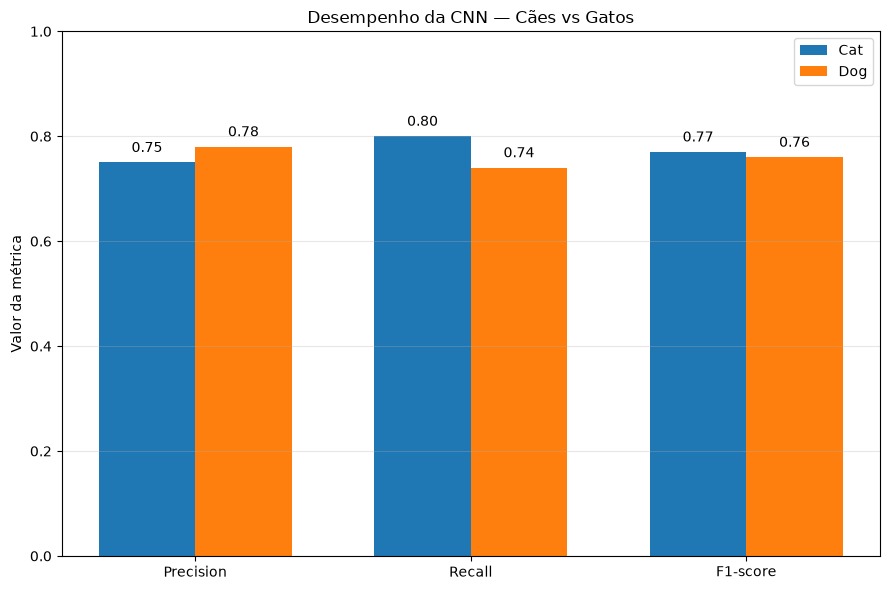

Gráfico salvo em: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\metricas_cnn.png


In [36]:
# Cria uma figura para o gráfico
fig, ax = plt.subplots(figsize=(9, 6))

# Define a posição de cada grupo de métricas no eixo horizontal
posicoes = np.arange(len(nomes_metricas))

# Define a largura das barras
largura = 0.35

# Cria as barras da classe Cat
barras_cat = ax.bar(
    posicoes - largura / 2,
    valores_cat,
    largura,
    label="Cat"
)

# Cria as barras da classe Dog
barras_dog = ax.bar(
    posicoes + largura / 2,
    valores_dog,
    largura,
    label="Dog"
)

# Define os nomes das métricas no eixo horizontal
ax.set_xticks(posicoes)
ax.set_xticklabels(nomes_metricas)

# Define o limite do eixo vertical entre 0 e 1
ax.set_ylim(0, 1)

# Define o título do gráfico
ax.set_title("Desempenho da CNN — Cães vs Gatos")

# Define o nome do eixo vertical
ax.set_ylabel("Valor da métrica")

# Mostra a legenda identificando Cat e Dog
ax.legend()

# Adiciona uma grade horizontal para facilitar a leitura
ax.grid(axis="y", alpha=0.3)

# Mostra o valor de cada métrica sobre as barras
for barras in [barras_cat, barras_dog]:

    # Percorre cada barra do grupo
    for barra in barras:

        # Obtém a altura da barra
        valor = barra.get_height()

        # Escreve o valor acima da barra
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.02,
            f"{valor:.2f}",
            ha="center"
        )

# Ajusta automaticamente os elementos da figura
plt.tight_layout()

# Define o caminho para salvar o gráfico
caminho_grafico = pasta_resultados / "metricas_cnn.png"

# Salva o gráfico como PNG
plt.savefig(caminho_grafico, dpi=150)

# Exibe o gráfico no notebook
plt.show()

# Confirma onde o gráfico foi salvo
print("Gráfico salvo em:", caminho_grafico)

In [37]:
# Cria uma lista para armazenar todos os quadros da animação
quadros_metricas = []

# Define quantos quadros serão utilizados para fazer as barras crescerem
quantidade_quadros = 20

# Percorre os níveis de crescimento das barras
for etapa in range(1, quantidade_quadros + 1):

    # Calcula o percentual de crescimento das barras
    progresso = etapa / quantidade_quadros

    # Cria uma nova figura para o quadro atual
    fig, ax = plt.subplots(figsize=(9, 6))

    # Define a posição das métricas no eixo horizontal
    posicoes = np.arange(len(nomes_metricas))

    # Define a largura das barras
    largura = 0.35

    # Calcula a altura atual das barras da classe Cat
    alturas_cat = np.array(valores_cat) * progresso

    # Calcula a altura atual das barras da classe Dog
    alturas_dog = np.array(valores_dog) * progresso

    # Cria as barras da classe Cat
    barras_cat = ax.bar(
        posicoes - largura / 2,
        alturas_cat,
        largura,
        label="Cat"
    )

    # Cria as barras da classe Dog
    barras_dog = ax.bar(
        posicoes + largura / 2,
        alturas_dog,
        largura,
        label="Dog"
    )

    # Define os nomes das métricas no eixo horizontal
    ax.set_xticks(posicoes)
    ax.set_xticklabels(nomes_metricas)

    # Mantém o eixo vertical fixo entre 0 e 1
    ax.set_ylim(0, 1)

    # Define o título do gráfico
    ax.set_title("Desempenho da CNN — Cães vs Gatos")

    # Define o nome do eixo vertical
    ax.set_ylabel("Valor da métrica")

    # Adiciona a legenda
    ax.legend()

    # Adiciona uma grade horizontal
    ax.grid(axis="y", alpha=0.3)

    # Adiciona os valores sobre as barras
    for barras in [barras_cat, barras_dog]:

        # Percorre as barras do grupo
        for barra in barras:

            # Obtém a altura atual da barra
            valor = barra.get_height()

            # Mostra o valor atual acima da barra
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                valor + 0.02,
                f"{valor:.2f}",
                ha="center"
            )

    # Ajusta o espaçamento da figura
    plt.tight_layout()

    # Salva a figura temporariamente na memória
    fig.canvas.draw()

    # Obtém a imagem renderizada da figura
    imagem = np.asarray(fig.canvas.buffer_rgba())

    # Converte a imagem para RGB
    imagem = imagem[:, :, :3].copy()

    # Adiciona o quadro à animação
    quadros_metricas.append(imagem)

    # Fecha a figura para liberar memória
    plt.close()

# Mostra quantos quadros foram criados
print("Quantidade de quadros:", len(quadros_metricas))

Quantidade de quadros: 20


In [39]:
# Define o caminho do GIF que será recriado
caminho_gif_metricas = pasta_resultados / "metricas_cnn_animado.gif"

# Recria o GIF utilizando os mesmos 20 quadros,
# mas mantendo cada quadro na tela por mais tempo
imageio.mimsave(
    caminho_gif_metricas,
    quadros_metricas,
    duration=0.5,
    loop=0
)

# Confirma que o GIF foi recriado
print("GIF mais lento criado com sucesso!")
print("Arquivo:", caminho_gif_metricas)
print("Duração aproximada da animação:", 10, "segundos")

GIF mais lento criado com sucesso!
Arquivo: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\metricas_cnn_animado.gif
Duração aproximada da animação: 10 segundos


In [42]:
# Define o caminho do GIF final
caminho_gif_metricas_final = pasta_resultados / "metricas_cnn_animado_final.gif"

# Cria uma nova lista com os quadros originais da animação
quadros_finais = list(quadros_metricas)

# Repete o último quadro 20 vezes
# Como cada quadro dura 0.5 segundo,
# isso cria uma pausa de aproximadamente 10 segundos
for _ in range(20):

    # Adiciona novamente o último quadro
    quadros_finais.append(quadros_metricas[-1])

# Salva novamente o GIF com a pausa maior
imageio.mimsave(
    caminho_gif_metricas_final,
    quadros_finais,
    duration=0.5,
    loop=0
)

# Calcula a duração aproximada de todo o GIF
duracao_total = len(quadros_finais) * 0.5

# Mostra as informações do arquivo
print("GIF atualizado com sucesso!")
print("Quantidade de quadros:", len(quadros_finais))
print("Duração aproximada:", duracao_total, "segundos")
print("Arquivo:", caminho_gif_metricas_final)

GIF atualizado com sucesso!
Quantidade de quadros: 40
Duração aproximada: 20.0 segundos
Arquivo: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\metricas_cnn_animado_final.gif


In [43]:
# Importa o Pandas para organizar os dados em uma tabela
import pandas as pd

# Gera o Classification Report em formato de dicionário
# Isso facilita salvar cada métrica separadamente
relatorio_dados = classification_report(
    rotulos_verdadeiros,
    previsoes_classes,
    target_names=["Cat", "Dog"],
    output_dict=True
)

# Converte o dicionário em um DataFrame
tabela_metricas = pd.DataFrame(relatorio_dados).transpose()

# Mostra a tabela de métricas no notebook
print(tabela_metricas)

              precision    recall  f1-score      support
Cat            0.751969  0.795281  0.773019  1441.000000
Dog            0.782769  0.737682  0.759557  1441.000000
accuracy       0.766482  0.766482  0.766482     0.766482
macro avg      0.767369  0.766482  0.766288  2882.000000
weighted avg   0.767369  0.766482  0.766288  2882.000000


In [44]:
# Define o caminho onde o relatório será salvo
caminho_relatorio = pasta_resultados / "classification_report.csv"

# Salva a tabela de métricas em formato CSV
tabela_metricas.to_csv(
    caminho_relatorio,
    index=True
)

# Verifica se o arquivo foi criado corretamente
if caminho_relatorio.exists():

    # Mostra o caminho completo do arquivo
    print("Classification Report salvo com sucesso!")
    print("Arquivo:", caminho_relatorio)

else:

    # Informa caso o arquivo não tenha sido encontrado
    print("O arquivo não foi criado.")

Classification Report salvo com sucesso!
Arquivo: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\resultados\matrizes_confusao\classification_report.csv


In [45]:
# Define o caminho da pasta onde os modelos treinados serão armazenados
pasta_modelos = Path(
    r"C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\modelos"
)

# Cria a pasta caso ela ainda não exista
pasta_modelos.mkdir(parents=True, exist_ok=True)

# Define o nome e o caminho do modelo treinado
caminho_modelo = pasta_modelos / "cnn_cao_gato.keras"

# Salva a arquitetura e os pesos do modelo treinado
modelo.save(caminho_modelo)

# Verifica se o arquivo foi criado
if caminho_modelo.exists():

    # Mostra o caminho completo do modelo salvo
    print("Modelo salvo com sucesso!")
    print("Arquivo:", caminho_modelo)

else:

    # Informa caso o arquivo não tenha sido encontrado
    print("O modelo não foi encontrado.")

Modelo salvo com sucesso!
Arquivo: C:\Users\Larissa\Documents\SCTECH\CNN_Cao_Gato\modelos\cnn_cao_gato.keras


In [46]:
# Obtém o tamanho do arquivo do modelo em bytes
tamanho_bytes = caminho_modelo.stat().st_size

# Converte o tamanho de bytes para megabytes
tamanho_mb = tamanho_bytes / (1024 ** 2)

# Mostra o tamanho do modelo
print(f"Tamanho do modelo: {tamanho_mb:.2f} MB")

Tamanho do modelo: 360.65 MB


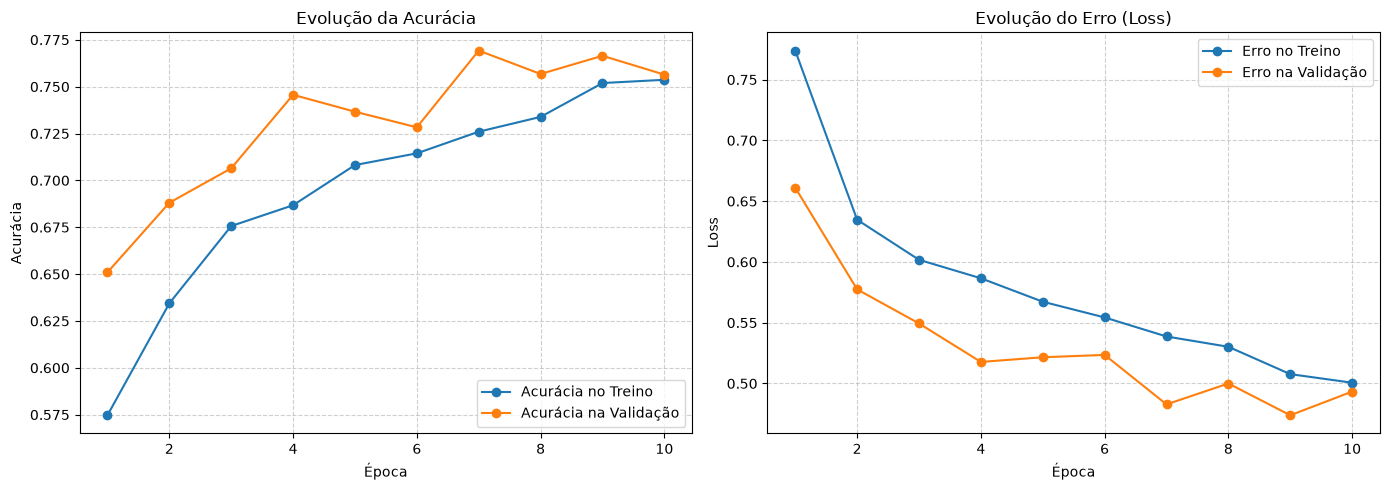

In [48]:
# ==========================================
# PLOTAGEM DOS GRÁFICOS DO TREINAMENTO
# ==========================================

import matplotlib.pyplot as plt

# Extrai a acurácia do conjunto de treinamento
acc = historico_tratado.history['accuracy']

# Extrai a acurácia do conjunto de validação
val_acc = historico_tratado.history['val_accuracy']

# Extrai o erro (loss) do conjunto de treinamento
loss = historico_tratado.history['loss']

# Extrai o erro (loss) do conjunto de validação
val_loss = historico_tratado.history['val_loss']

# Cria o eixo X com a quantidade real de épocas treinadas
# O +1 é utilizado porque o range começa em 0
epochs_range = range(1, len(acc) + 1)

# Cria uma figura com dois gráficos lado a lado
plt.figure(figsize=(14, 5))

# ==========================================
# GRÁFICO 1 — ACURÁCIA
# ==========================================

plt.subplot(1, 2, 1)

# Plota a acurácia do treinamento
plt.plot(
    epochs_range,
    acc,
    label='Acurácia no Treino',
    marker='o'
)

# Plota a acurácia da validação
plt.plot(
    epochs_range,
    val_acc,
    label='Acurácia na Validação',
    marker='o'
)

# Define os nomes dos eixos
plt.xlabel('Época')
plt.ylabel('Acurácia')

# Mostra a legenda
plt.legend(loc='lower right')

# Define o título
plt.title('Evolução da Acurácia')

# Adiciona uma grade para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# ==========================================
# GRÁFICO 2 — LOSS
# ==========================================

plt.subplot(1, 2, 2)

# Plota o erro do treinamento
plt.plot(
    epochs_range,
    loss,
    label='Erro no Treino',
    marker='o'
)

# Plota o erro da validação
plt.plot(
    epochs_range,
    val_loss,
    label='Erro na Validação',
    marker='o'
)

# Define os nomes dos eixos
plt.xlabel('Época')
plt.ylabel('Loss')

# Mostra a legenda
plt.legend(loc='upper right')

# Define o título
plt.title('Evolução do Erro (Loss)')

# Adiciona uma grade para facilitar a leitura
plt.grid(True, linestyle='--', alpha=0.6)

# Ajusta automaticamente os espaços entre os gráficos
plt.tight_layout()

# Exibe os gráficos
plt.show()